# Unemployment Rate Forecasting — Republic of Kazakhstan

**Target:** Monthly unemployment rate $y_t$ (%, 2010–2025)

| Split | Period | $n$ |
|-------|--------|-----|
| Train | 2015-01 $\to$ 2023-12 | 108 |
| Test  | 2024-01 $\to$ 2025-12 | 24  |

**Models (8):** SARIMA $\cdot$ SARIMAX $\cdot$ ARDL $\cdot$ Elastic Net $\cdot$ Ridge $\cdot$ Random Forest $\cdot$ ANN (MLP) $\cdot$ RNN (LSTM)

**Feature engineering:** All non-stationary regressors enter as first-differences
$\Delta x_t = x_t - x_{t-1}$, plus autoregressive lags $y_{t-1}$, $y_{t-12}$.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings, re
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.linear_model import ElasticNetCV, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error
import statsmodels.api as sm
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'serif', 'mathtext.fontset': 'cm',
    'axes.labelsize': 12, 'font.size': 11, 'legend.fontsize': 10,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'figure.figsize': (12, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'figure.dpi': 130, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
print("Libraries loaded.")

Libraries loaded.


## 1 $\cdot$ Data Loading

### Sources
| File | Content |
|------|---------|
| `diploma_dataset.xlsx` | Compiled macro indicators (192 months, 0 missing) |
| `National Bank Base Rate.xlsx` | Central bank repo rate (irregular $\to$ monthly) |
| `USD_TENGE.xlsx` | Daily USD/KZT (5 863 obs $\to$ monthly mean + volatility) |
| `RUB_KZT_mon.csv` | Monthly RUB/KZT — only 24 months, so **historical data is derived from yfinance** (`USD/KZT ÷ USD/RUB`) |

**CPI columns are excluded** — CPI forecasting is handled in a separate module.

> **Missing datasets (upload to improve the model):**
> `STEI` (Short-Term Economic Indicator), `Retail_Trade`, `Industrial_Production`
> — available from [stat.gov.kz](https://stat.gov.kz)

In [100]:
DATA = './data/'

# ── 1a. Primary dataset ──
raw = pd.read_excel(DATA + 'cpi_data/diploma_dataset.xlsx')
raw['Date'] = pd.to_datetime(raw['Date'])
raw = raw.set_index('Date').sort_index()
raw = raw.rename(columns={'Unemployement': 'unemployed_rate'})

cpi_cols = [c for c in raw.columns if c not in [
    'gold_price_usd_avg', 'usd_kzt', 'interest_rate',
    'Oil_crude_brent', 'GDP_growth', 'unemployed_rate'
]]
df = raw.drop(columns=cpi_cols).copy()
print(f"Dropped {len(cpi_cols)} CPI columns.")

# ── 1b. National Bank Base Rate ──
nbk = pd.read_excel(DATA + 'unemp/National Bank Base Rate.xlsx')
nbk.columns = ['Date_str', 'Base_Rate', 'Corridor']
nbk = nbk.dropna(subset=['Base_Rate'])
nbk['Date'] = pd.to_datetime(
    nbk['Date_str'].str.replace('*', '', regex=False),
    format='%d.%m.%Y', dayfirst=True, errors='coerce')
nbk['Base_Rate'] = nbk['Base_Rate'].astype(str).str.replace(',', '.').astype(float)
nbk = nbk[['Date', 'Base_Rate']].dropna().set_index('Date').sort_index()
nbk_monthly = nbk.resample('MS').ffill()
df = df.join(nbk_monthly, how='left')
df['Base_Rate'] = df['Base_Rate'].bfill()

# ── 1c. USD/KZT daily -> monthly mean + volatility ──
usd_raw = pd.read_excel(DATA + 'unemp/USD_TENGE.xlsx')
_date = pd.to_datetime(usd_raw.iloc[:, 0], dayfirst=True, errors='coerce')
_quant = pd.to_numeric(usd_raw.iloc[:, 1], errors='coerce').fillna(1)
_tenge = pd.to_numeric(usd_raw.iloc[:, 2], errors='coerce')
_rate = (_tenge / _quant)
usd_daily = pd.DataFrame({'usd_kzt_daily': _rate.values}, index=_date).sort_index()
df = df.join(usd_daily.resample('MS').mean(), how='left')
df = df.join(usd_daily.resample('MS').std().rename(
    columns={'usd_kzt_daily': 'usd_kzt_volatility'}), how='left')
df['usd_kzt_volatility'] = df['usd_kzt_volatility'].fillna(0)

# ── 1d. RUB/KZT — derive historical series from yfinance ──
import yfinance as yf

# Download USD/RUB and compute RUB/KZT = USD_KZT / USD_RUB
usdrub = yf.download('RUBUSD=X', start='2010-01-01', progress=False)
if usdrub.empty:
    usdrub = yf.download('RUB=X', start='2010-01-01', progress=False)

if not usdrub.empty:
    usdrub_monthly = usdrub[['Close']].resample('MS').mean()
    usdrub_monthly.columns = ['USD_RUB']
    usdrub_monthly.index.name = 'Date'
    # RUB/KZT = how many tenge per 1 ruble
    merged_fx = usd_daily.resample('MS').mean().join(usdrub_monthly, how='inner')
    merged_fx['rub_kzt'] = merged_fx['usd_kzt_daily'] * merged_fx['USD_RUB']
    df = df.join(merged_fx[['rub_kzt']], how='left')
    print(f"Derived RUB/KZT: {df['rub_kzt'].notna().sum()} months")
else:
    # Fallback: use the 24-month local file
    rub_local = pd.read_csv(DATA + 'unemp/RUB_KZT_mon.csv')
    rub_local['Date'] = pd.to_datetime(rub_local['Date'], format='%m/%d/%Y')
    rub_local = rub_local.set_index('Date')[['Price']].sort_index()
    rub_local.columns = ['rub_kzt']
    rub_local = rub_local.resample('MS').mean()
    df = df.join(rub_local, how='left')
    print(f"Local RUB/KZT: {df['rub_kzt'].notna().sum()} months (limited!)")

df = df.ffill().bfill()

print(f"\nFinal dataset: {df.shape[0]} months x {df.shape[1]} columns")
print(f"Date range: {df.index.min().date()} -> {df.index.max().date()}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isna().sum()}")
df.tail()

Dropped 13 CPI columns.
Derived RUB/KZT: 190 months

Final dataset: 192 months x 10 columns
Date range: 2010-01-01 -> 2025-12-01

Columns: ['gold_price_usd_avg', 'usd_kzt', 'interest_rate', 'Oil_crude_brent', 'GDP_growth', 'unemployed_rate', 'Base_Rate', 'usd_kzt_daily', 'usd_kzt_volatility', 'rub_kzt']

Missing values:
gold_price_usd_avg    0
usd_kzt               0
interest_rate         0
Oil_crude_brent       0
GDP_growth            0
unemployed_rate       0
Base_Rate             0
usd_kzt_daily         0
usd_kzt_volatility    0
rub_kzt               0
dtype: int64


,gold_price_usd_avg,usd_kzt,interest_rate,Oil_crude_brent,GDP_growth,unemployed_rate,Base_Rate,usd_kzt_daily,usd_kzt_volatility,rub_kzt
Date,,,,,,,,,,
2025-08-01,3372.742839,539.2526,16.5,67.87,6.5,4.6,16.5,539.252581,2.304840,6.750144
2025-09-01,3682.299991,540.7487,16.5,67.99,6.5,4.6,16.5,540.748667,2.784561,6.545840
2025-10-01,4044.373907,539.9552,18.0,64.54,6.5,4.6,16.5,539.955161,4.887443,6.674792
2025-11-01,4082.115761,522.4703,18.0,63.80,6.5,4.6,18.0,522.470333,4.729126,6.512260
2025-12-01,4311.059104,512.5300,18.0,62.54,6.5,4.6,18.0,511.934839,6.814570,6.533496


## 2 $\cdot$ Data Validation & Missing-Value Treatment

After ffill/bfill:
gold_price_usd_avg    0
usd_kzt               0
interest_rate         0
Oil_crude_brent       0
GDP_growth            0
unemployed_rate       0
Base_Rate             0
usd_kzt_daily         0
usd_kzt_volatility    0
rub_kzt               0
dtype: int64

Target unique values: 17
Target range: 4.6% — 6.3%


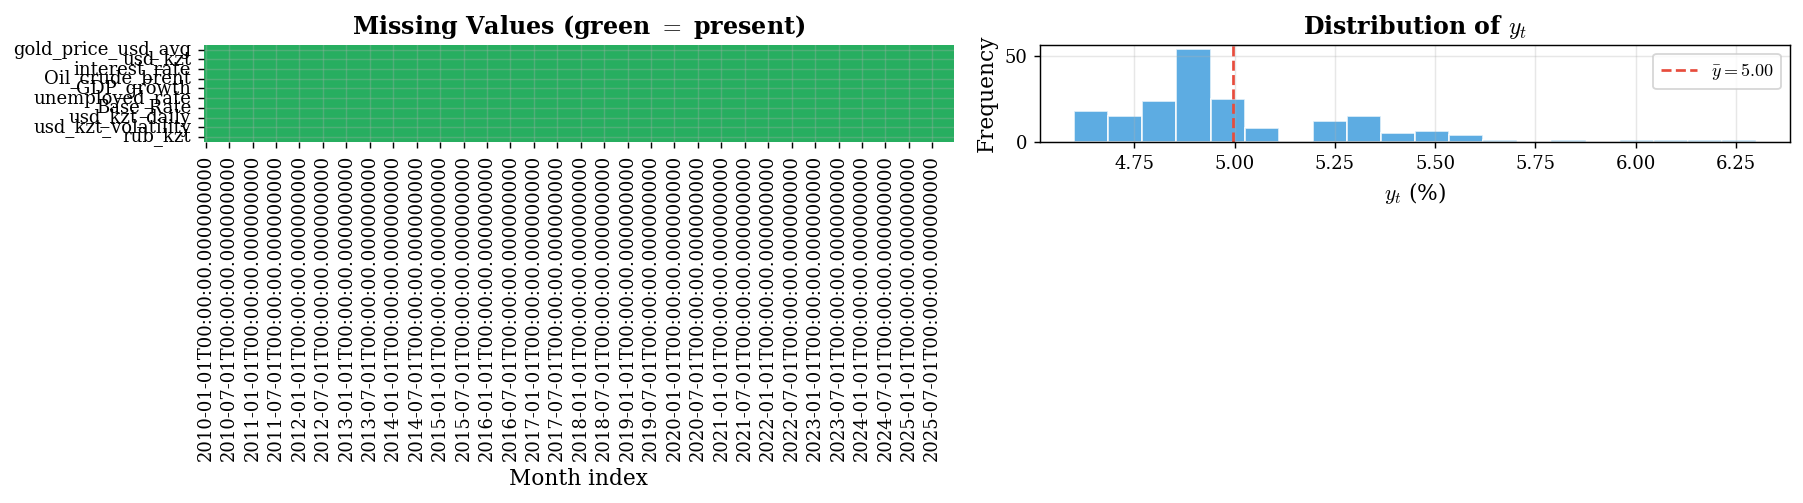

In [101]:
print("After ffill/bfill:")
print(df.isna().sum())
print(f"\nTarget unique values: {df['unemployed_rate'].nunique()}")
print(f"Target range: {df['unemployed_rate'].min():.1f}% — {df['unemployed_rate'].max():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
sns.heatmap(df.isna().T, cbar=False, yticklabels=True,
            cmap=['#27ae60', '#e74c3c'], ax=ax)
ax.set_title('Missing Values (green $=$ present)', fontweight='bold')
ax.set_xlabel('Month index')

ax = axes[1]
ax.hist(df['unemployed_rate'], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
ax.axvline(df['unemployed_rate'].mean(), color='#e74c3c', ls='--', lw=1.5,
           label=rf'$\bar{{y}} = {df["unemployed_rate"].mean():.2f}$')
ax.set_xlabel(r'$y_t$ (%)'); ax.set_ylabel('Frequency')
ax.set_title(r'Distribution of $y_t$', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 3 $\cdot$ Exploratory Data Analysis

### 3.1 Time-Series Plots

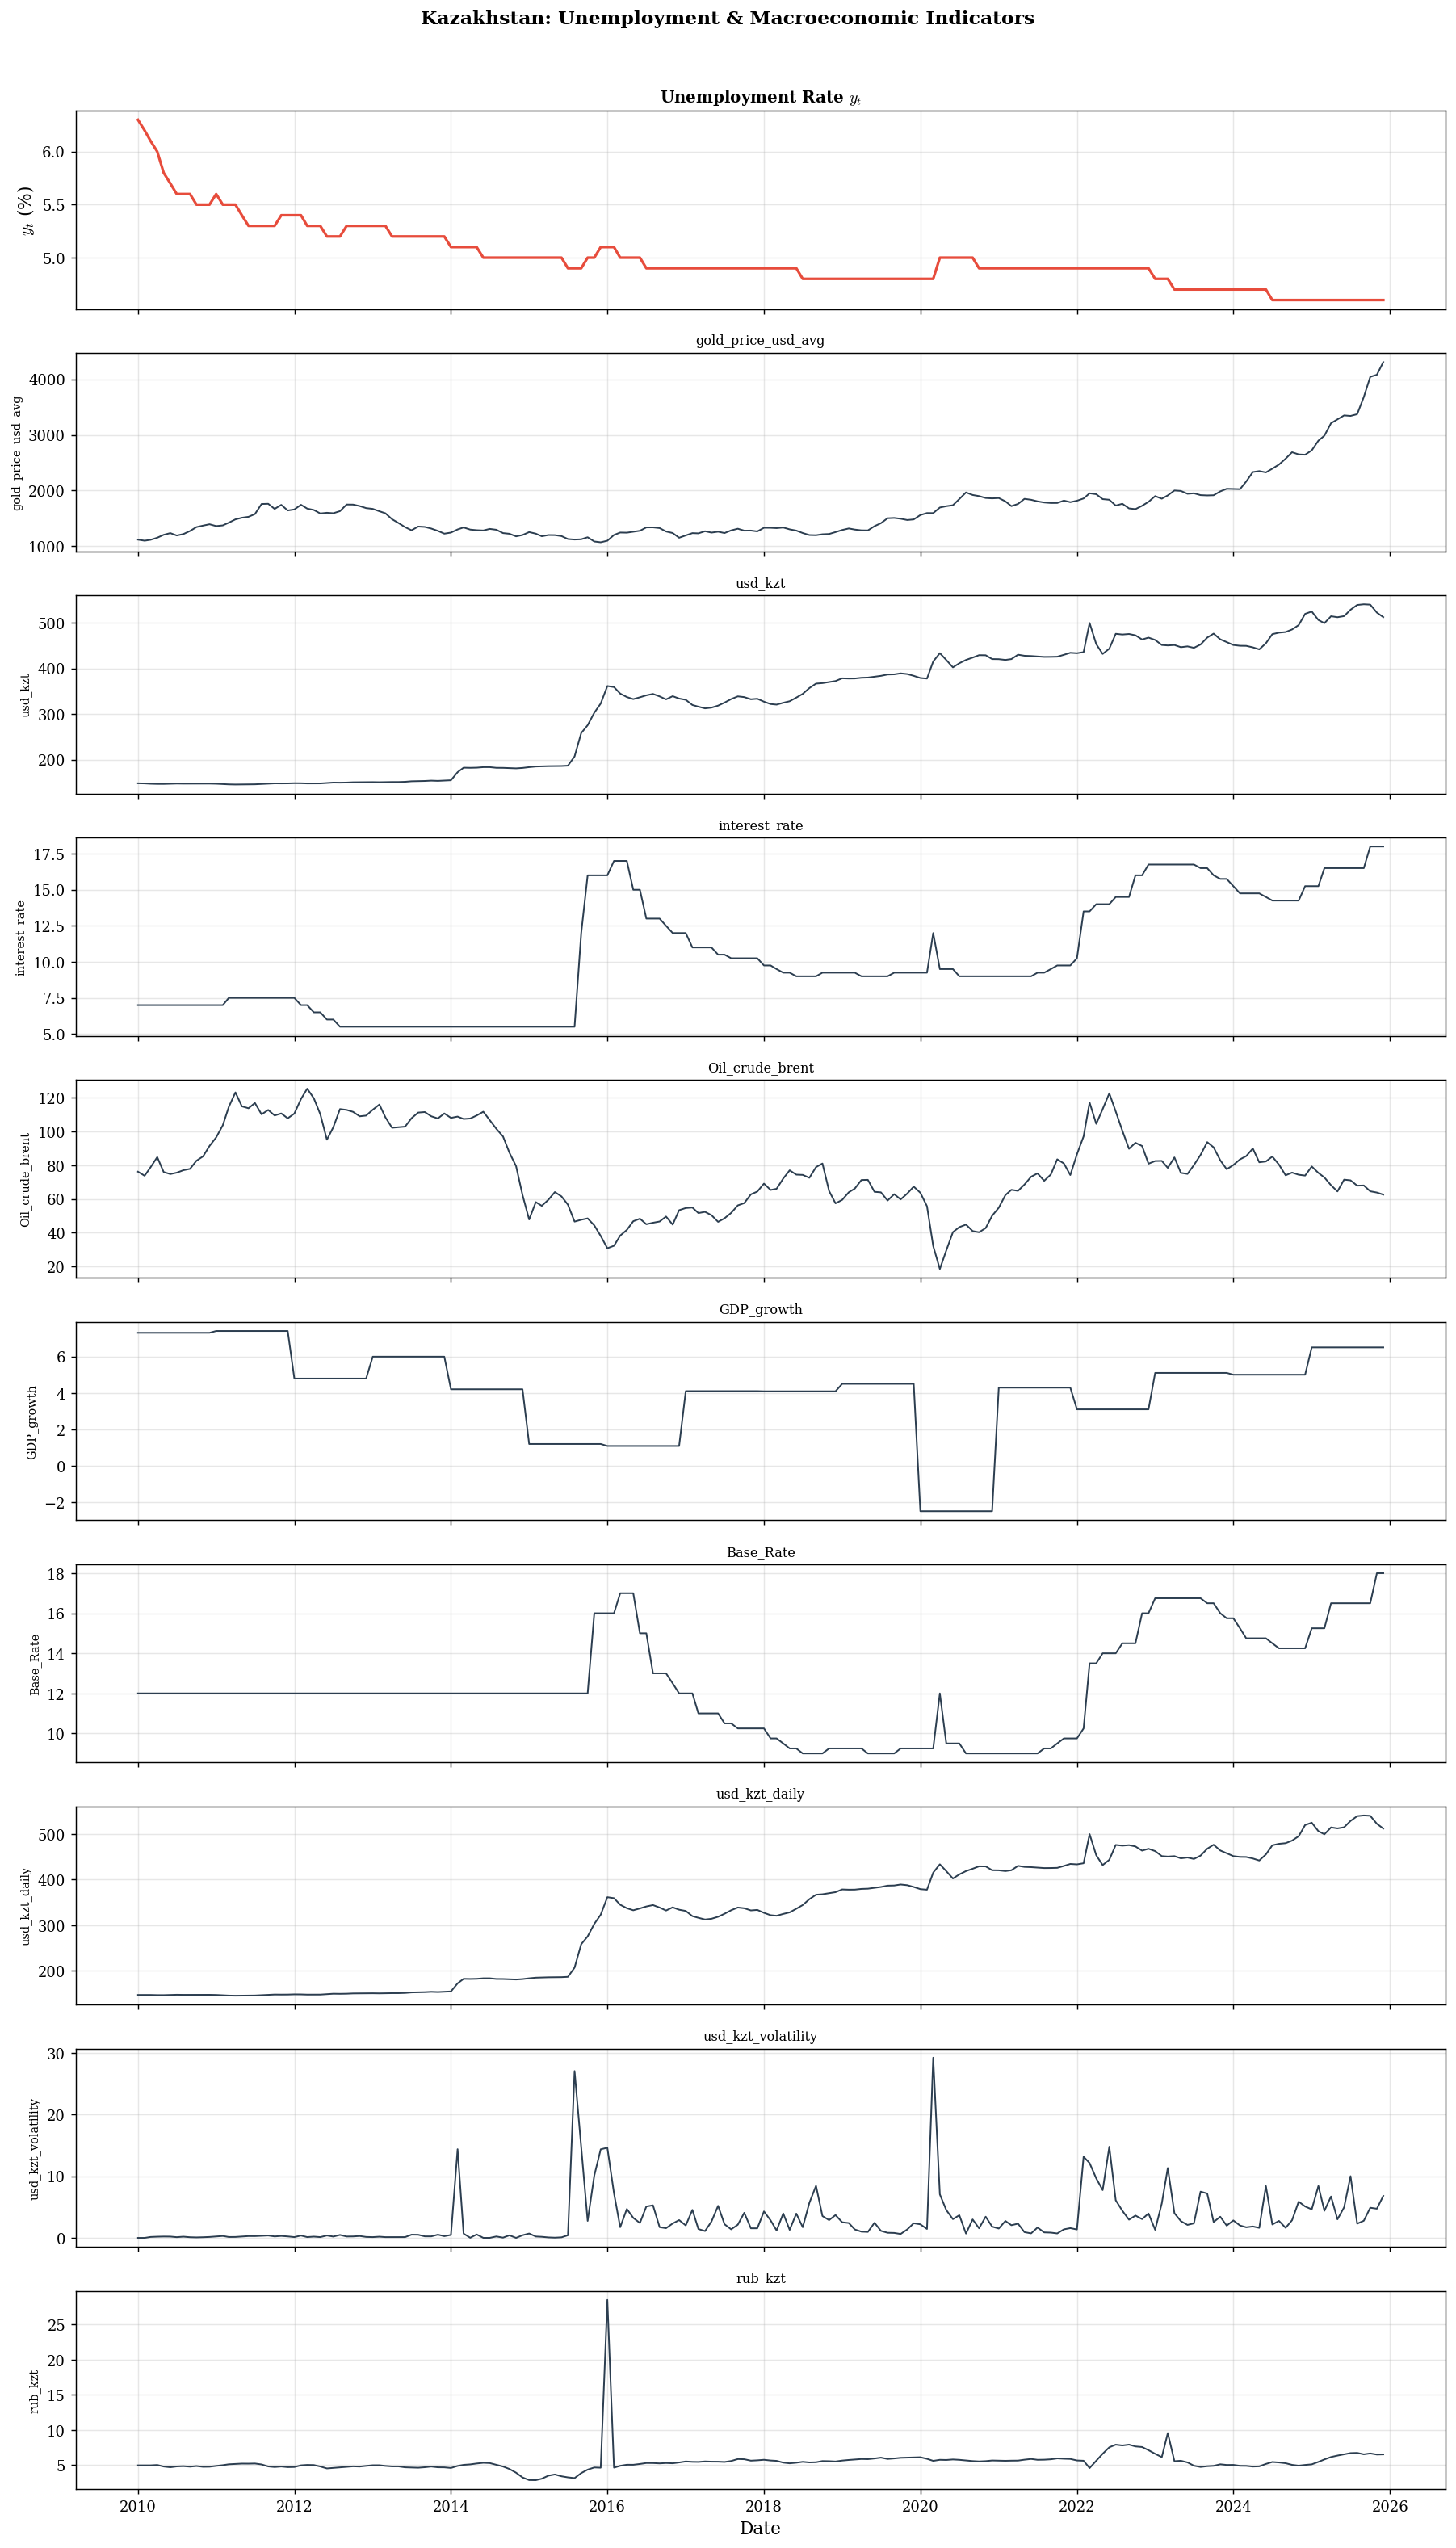

In [102]:
feature_cols = [c for c in df.columns if c != 'unemployed_rate']
n = len(feature_cols) + 1
fig, axes = plt.subplots(n, 1, figsize=(14, 2.4 * n), sharex=True)

ax = axes[0]
ax.plot(df.index, df['unemployed_rate'], color='#e74c3c', lw=1.8)
ax.set_ylabel(r'$y_t$ (%)')
ax.set_title(r'Unemployment Rate $y_t$', fontsize=11, fontweight='bold')

for i, col in enumerate(feature_cols, 1):
    axes[i].plot(df.index, df[col], color='#2c3e50', lw=1.1)
    axes[i].set_ylabel(col, fontsize=8)
    axes[i].set_title(col, fontsize=9)

axes[-1].set_xlabel('Date')
plt.suptitle('Kazakhstan: Unemployment & Macroeconomic Indicators',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Correlation Analysis

Pearson $\rho_{xy}$ on **levels** vs **first-differences** $\Delta x_t = x_t - x_{t-1}$.

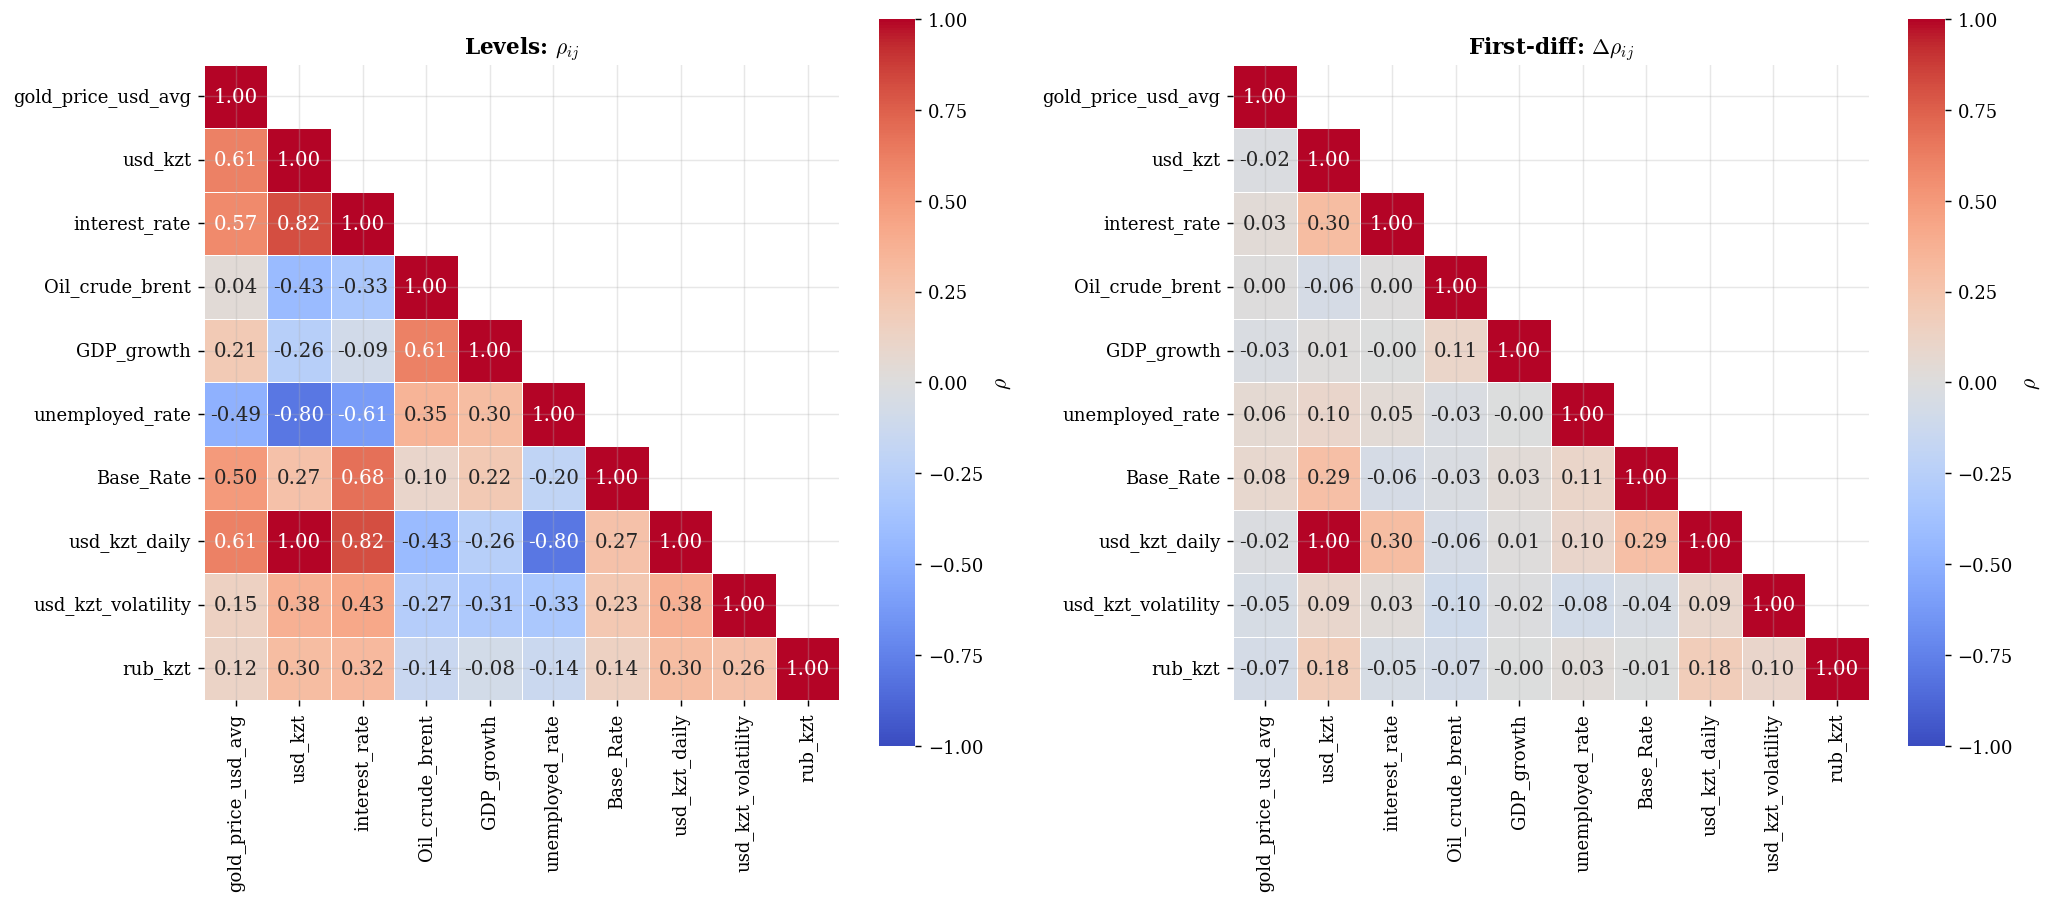


Correlation with unemployed_rate (first-differences):
usd_kzt_volatility   -0.082563
Oil_crude_brent      -0.026967
GDP_growth           -0.002723
rub_kzt               0.027696
interest_rate         0.046135
gold_price_usd_avg    0.059450
usd_kzt_daily         0.098582
usd_kzt               0.099790
Base_Rate             0.105473
Name: unemployed_rate, dtype: float64


In [103]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (title, data) in zip(axes, [
    (r'Levels: $\rho_{ij}$', df),
    (r'First-diff: $\Delta\rho_{ij}$', df.diff().dropna()),
]):
    corr = data.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, square=True, ax=ax,
                linewidths=.5, cbar_kws={'label': r'$\rho$'})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCorrelation with unemployed_rate (first-differences):")
print(df.diff().dropna().corr()['unemployed_rate'].drop('unemployed_rate').sort_values())

### 3.3 Stationarity Testing (ADF)

$$H_0: \text{unit root (non-stationary)} \quad\text{vs}\quad H_1: \text{stationary}$$

Reject $H_0$ when $p < 0.05$.

In [104]:
adf_results = []
for col in df.columns:
    stat, p, *_ = adfuller(df[col].dropna(), autolag='AIC')
    adf_results.append({'Variable': col, 'ADF Stat': round(stat, 3),
                        'p-value': round(p, 4),
                        'Stationary': 'Yes' if p < 0.05 else 'No'})
adf_df = pd.DataFrame(adf_results).set_index('Variable')
print(adf_df.to_string())

                    ADF Stat  p-value Stationary
Variable                                        
gold_price_usd_avg     4.701   1.0000         No
usd_kzt               -0.419   0.9069         No
interest_rate         -1.110   0.7111         No
Oil_crude_brent       -1.897   0.3334         No
GDP_growth            -2.057   0.2623         No
unemployed_rate       -5.775   0.0000        Yes
Base_Rate             -0.744   0.8349         No
usd_kzt_daily         -0.426   0.9057         No
usd_kzt_volatility    -5.072   0.0000        Yes
rub_kzt               -7.952   0.0000        Yes


### 3.4 Seasonal Decomposition & ACF/PACF

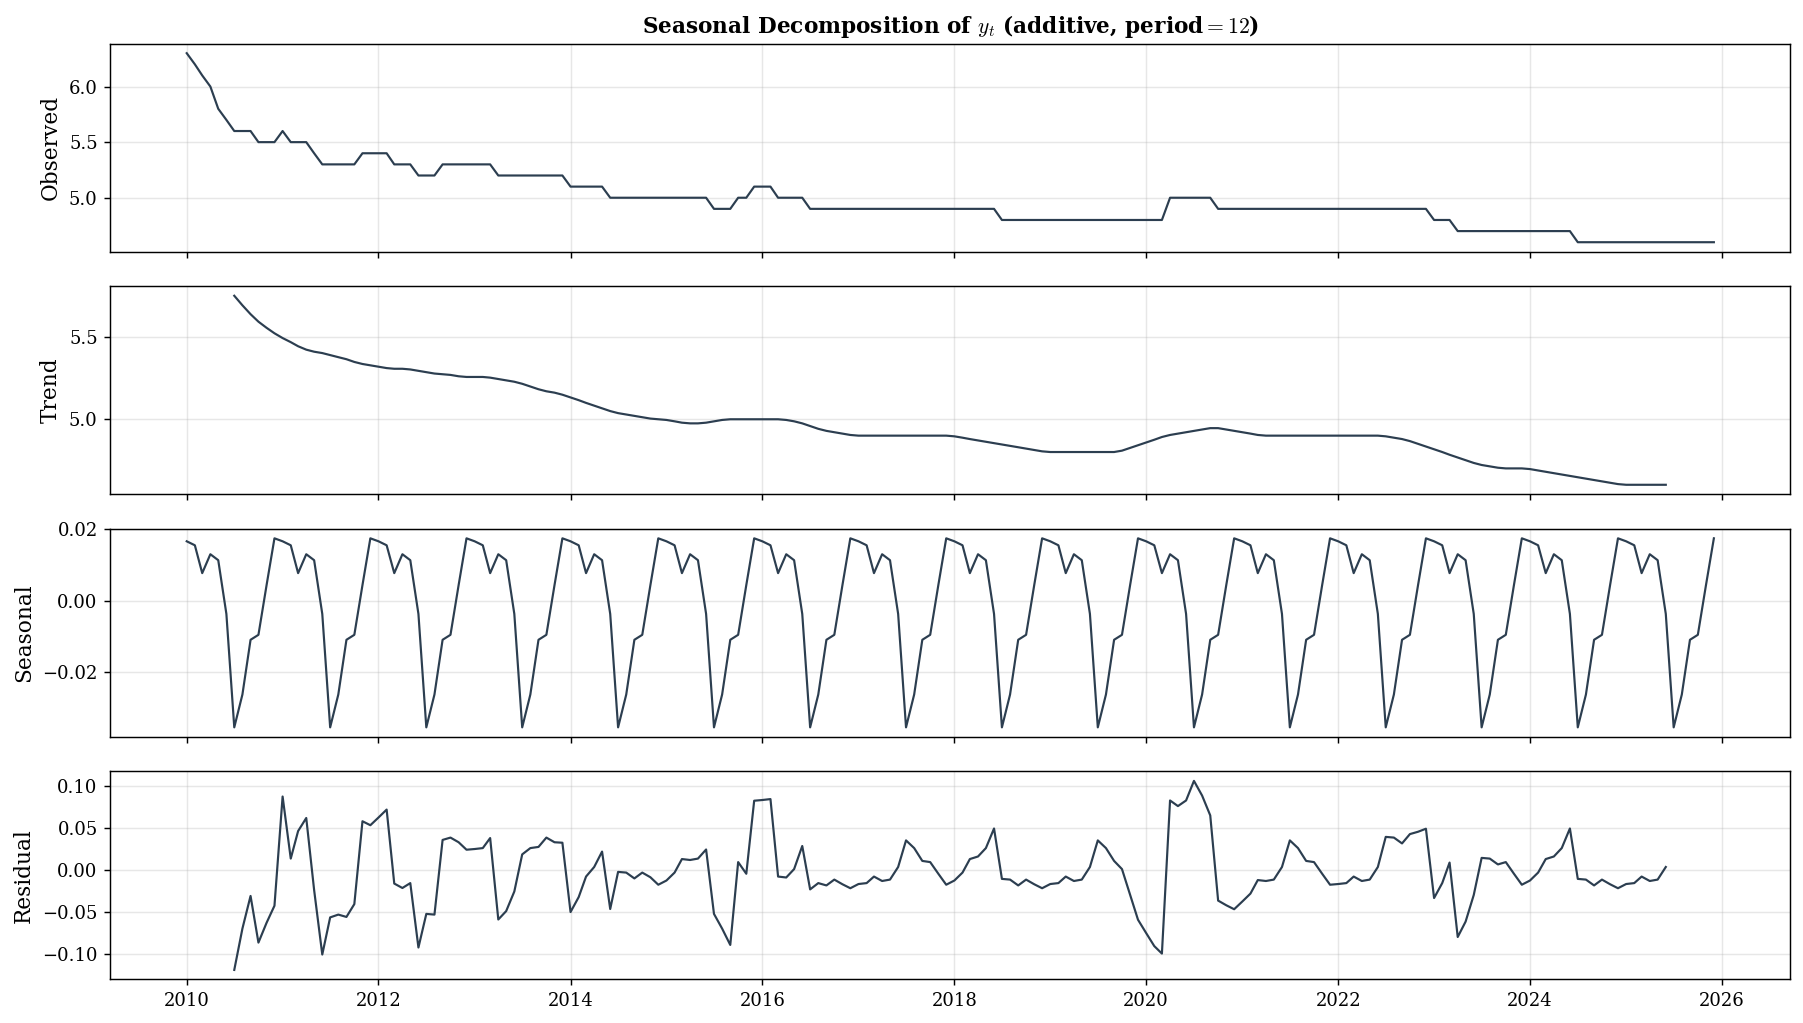

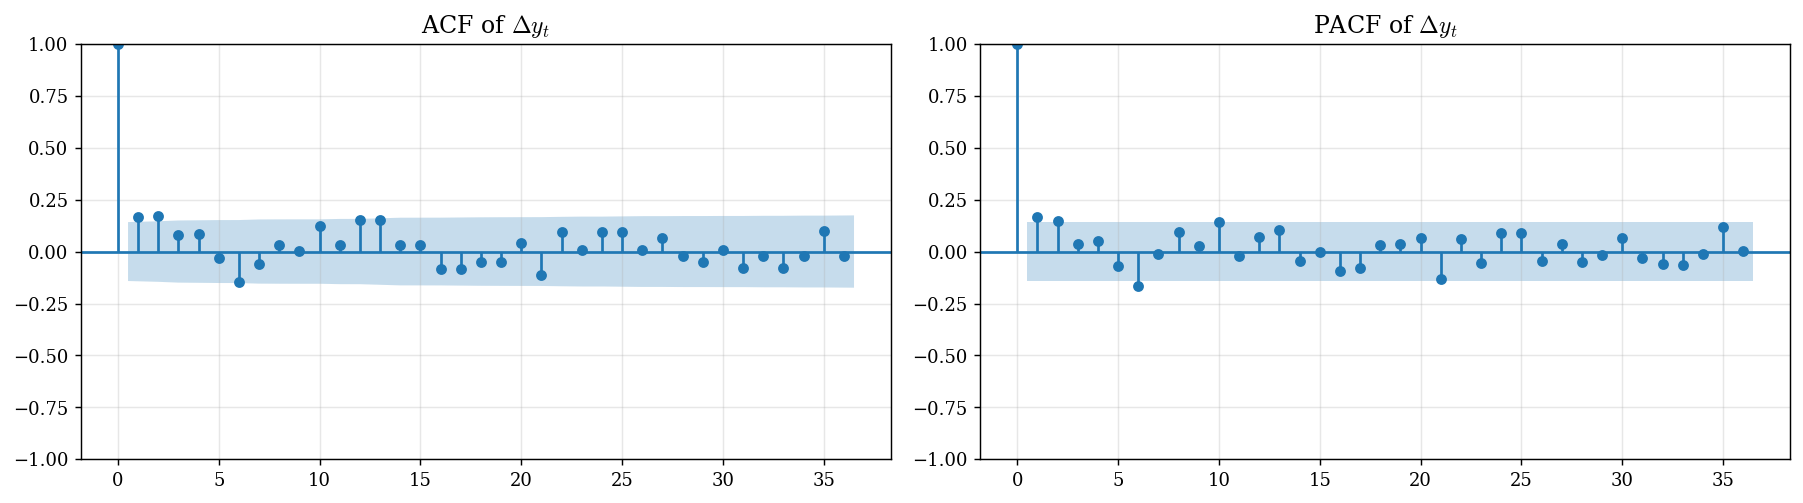

In [105]:
decomp = seasonal_decompose(df['unemployed_rate'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for ax, (lab, comp) in zip(axes, [
    ('Observed', decomp.observed), ('Trend', decomp.trend),
    ('Seasonal', decomp.seasonal), ('Residual', decomp.resid)
]):
    ax.plot(comp, color='#2c3e50', lw=1.2)
    ax.set_ylabel(lab)
axes[0].set_title(r'Seasonal Decomposition of $y_t$ (additive, period$=12$)',
                  fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

y_diff = df['unemployed_rate'].diff().dropna()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(y_diff, lags=36, ax=axes[0], title=r'ACF of $\Delta y_t$')
plot_pacf(y_diff, lags=36, ax=axes[1], title=r'PACF of $\Delta y_t$', method='ywm')
plt.tight_layout()
plt.show()

### 3.5 Outlier Detection (IQR)

Outlier counts (IQR):
gold_price_usd_avg    13
GDP_growth            36
unemployed_rate        6
usd_kzt_volatility    13
rub_kzt               16


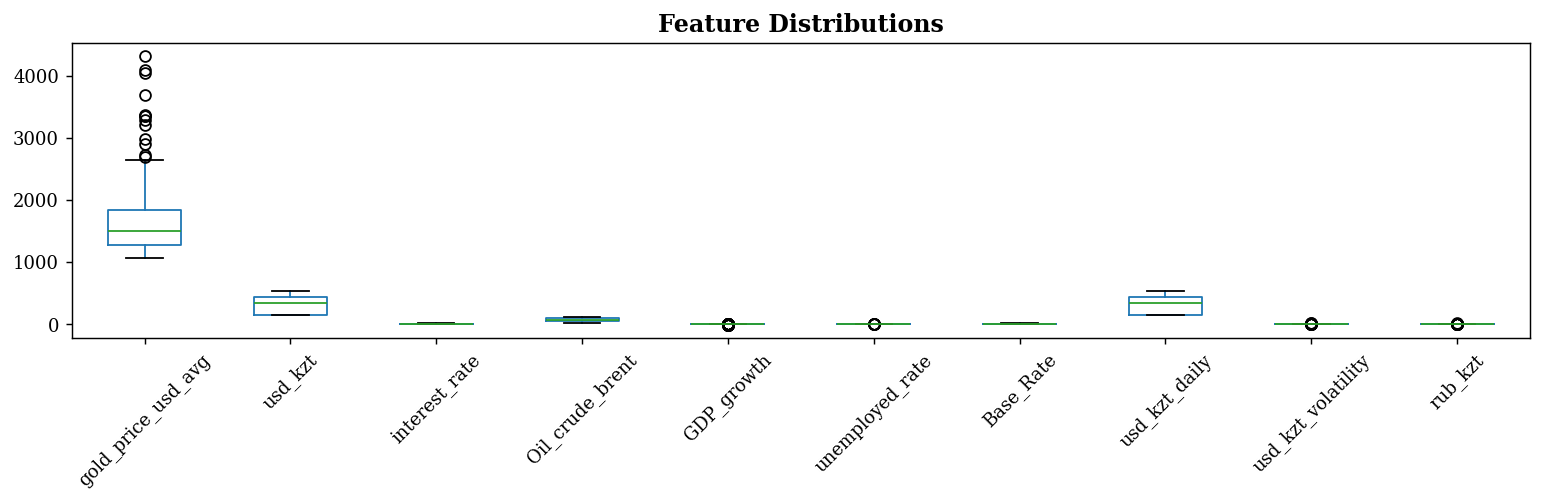

In [106]:
Q1, Q3 = df.quantile(0.25), df.quantile(0.75)
IQR = Q3 - Q1
outliers = ((df < Q1 - 1.5 * IQR) | (df > Q3 + 1.5 * IQR)).sum()
print("Outlier counts (IQR):")
print(outliers[outliers > 0].to_string() if outliers.sum() > 0 else "No outliers.")

fig, ax = plt.subplots(figsize=(12, 4))
df.boxplot(ax=ax, rot=45, grid=False)
ax.set_title('Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

## 4 $\cdot$ Feature Engineering — Stationarity via Differencing

Non-stationary regressors are transformed to first-differences:

$$\Delta x_t = x_t - x_{t-1}$$

This removes unit-root trends and makes the feature set suitable for regression.

**Final feature matrix:**

| Feature | Transformation |
|---------|---------------|
| $y_{t-1}$, $y_{t-12}$ | Autoregressive lags of the target |
| `usd_kzt_diff` | $\Delta\text{USD/KZT}_t$ |
| `Oil_crude_brent_diff` | $\Delta\text{Brent}_t$ |
| `Base_Rate_diff` | $\Delta\text{Base Rate}_t$ |
| `rub_kzt_diff` | $\Delta\text{RUB/KZT}_t$ |
| `GDP_growth` | Already a rate (YoY %), kept as-is |
| `interest_rate` | Level — captures policy stance |
| `gold_price_usd_avg` | Level — safe-haven proxy |
| `usd_kzt_volatility` | Derived (monthly std of daily rates) |

> **Not available yet:** `STEI`, `Retail_Trade_diff`, `Industrial_Production_diff`.
> Upload these from [stat.gov.kz](https://stat.gov.kz) to complete the full specification.

In [107]:
df_model = df.copy()

# ── First-differences for non-stationary regressors ──
diff_cols = ['usd_kzt', 'Oil_crude_brent', 'Base_Rate']
if 'rub_kzt' in df_model.columns:
    diff_cols.append('rub_kzt')

for col in diff_cols:
    df_model[f'{col}_diff'] = df_model[col].diff()

# Drop raw level columns that were differenced
df_model.drop(columns=diff_cols, inplace=True)

# Also drop usd_kzt_daily (redundant with usd_kzt from diploma_dataset)
if 'usd_kzt_daily' in df_model.columns:
    df_model.drop(columns=['usd_kzt_daily'], inplace=True)

# ── Autoregressive lags ──
df_model['y_lag1']  = df_model['unemployed_rate'].shift(1)
df_model['y_lag12'] = df_model['unemployed_rate'].shift(12)

# Drop NaN rows created by differencing + lagging
df_model.dropna(inplace=True)

print(f"Modeling dataset: {df_model.shape}")
print(f"Date range: {df_model.index.min().date()} -> {df_model.index.max().date()}")
print(f"\nFeatures: {[c for c in df_model.columns if c != 'unemployed_rate']}")

Modeling dataset: (180, 11)
Date range: 2011-01-01 -> 2025-12-01

Features: ['gold_price_usd_avg', 'interest_rate', 'GDP_growth', 'usd_kzt_volatility', 'usd_kzt_diff', 'Oil_crude_brent_diff', 'Base_Rate_diff', 'rub_kzt_diff', 'y_lag1', 'y_lag12']


## 5 $\cdot$ Forecasting Models

### Evaluation Metrics

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$$

$$\text{MASE} = \frac{\text{MAE}}{\frac{1}{n-1}\sum_{i=2}^{n}|y_i - y_{i-1}|}$$

In [108]:
y = df_model['unemployed_rate']
X = df_model.drop(columns=['unemployed_rate'])

y_train, y_test = y.loc[:'2023-12-01'], y.loc['2024-01-01':]
X_train, X_test = X.loc[:'2023-12-01'], X.loc['2024-01-01':]

forecasts = {}
results_list = []

def evaluate(name, actual, predicted, train_y):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)
    naive_mae = np.mean(np.abs(np.diff(train_y)))
    mase = mae / naive_mae if naive_mae > 0 else np.nan
    print(f'[{name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R2={r2:.4f}  MASE={mase:.4f}')
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MASE': mase}

print(f'Train: {y_train.index.min().date()} -> {y_train.index.max().date()} | n={len(y_train)}')
print(f'Test:  {y_test.index.min().date()} -> {y_test.index.max().date()} | n={len(y_test)}')
print(f'Features ({X_train.shape[1]}): {list(X_train.columns)}')

Train: 2011-01-01 -> 2023-12-01 | n=156
Test:  2024-01-01 -> 2025-12-01 | n=24
Features (10): ['gold_price_usd_avg', 'interest_rate', 'GDP_growth', 'usd_kzt_volatility', 'usd_kzt_diff', 'Oil_crude_brent_diff', 'Base_Rate_diff', 'rub_kzt_diff', 'y_lag1', 'y_lag12']


### Model 1 — SARIMA$(2,1,1)(1,1,1)_{12}$

Pure univariate baseline.

$$\Phi(B^{12})\,\phi(B)\,(1-B)(1-B^{12})\,y_t = c + \Theta(B^{12})\,\theta(B)\,\varepsilon_t$$

In [109]:
sarima = SARIMAX(y_train, order=(2,1,1), seasonal_order=(1,1,1,12),
                 trend='c', enforce_stationarity=False, enforce_invertibility=False)
sarima_res = sarima.fit(disp=False)
sarima_pred = sarima_res.get_forecast(steps=len(y_test)).predicted_mean
sarima_pred.index = y_test.index
forecasts['SARIMA'] = sarima_pred
results_list.append(evaluate('SARIMA', y_test, sarima_pred, y_train))
print(sarima_res.summary())

[SARIMA]  MAE=0.0604  RMSE=0.0682  R2=-1.4823  MASE=4.4553
                                     SARIMAX Results                                      
Dep. Variable:                    unemployed_rate   No. Observations:                  156
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 231.727
Date:                            Tue, 31 Mar 2026   AIC                           -449.455
Time:                                    16:07:05   BIC                           -429.436
Sample:                                01-01-2011   HQIC                          -441.321
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3.886e-05      0.000      0.212      0.832 

### Model 2 — SARIMAX$(2,1,1)(1,1,1)_{12}$ + exogenous

Adds differenced structural drivers as external regressors.

In [110]:
exog_cols = [c for c in X_train.columns if c.endswith('_diff')]

sarimax = SARIMAX(y_train, exog=X_train[exog_cols],
                  order=(2,1,1), seasonal_order=(1,1,1,12),
                  trend='c', enforce_stationarity=False, enforce_invertibility=False)
sarimax_res = sarimax.fit(disp=False)
sarimax_pred = sarimax_res.get_forecast(
    steps=len(y_test), exog=X_test[exog_cols]).predicted_mean
sarimax_pred.index = y_test.index
forecasts['SARIMAX'] = sarimax_pred
results_list.append(evaluate('SARIMAX', y_test, sarimax_pred, y_train))
print(sarimax_res.summary())

[SARIMAX]  MAE=0.0401  RMSE=0.0427  R2=0.0262  MASE=2.9600
                                     SARIMAX Results                                      
Dep. Variable:                    unemployed_rate   No. Observations:                  156
Model:             SARIMAX(2, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 230.261
Date:                            Tue, 31 Mar 2026   AIC                           -438.521
Time:                                    16:07:06   BIC                           -407.063
Sample:                                01-01-2011   HQIC                          -425.739
                                     - 12-01-2023                                         
Covariance Type:                              opg                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
intercept             1.894e-05    

### Model 3 — ARDL

$$y_t = \alpha + \beta_1 y_{t-1} + \beta_{12} y_{t-12} + \gamma'\Delta X_t + \varepsilon_t$$

Estimated via OLS with HC1 robust standard errors.

In [111]:
X_ardl_train = sm.add_constant(X_train, has_constant='add')
X_ardl_test  = sm.add_constant(X_test,  has_constant='add')

ardl_ols  = sm.OLS(y_train, X_ardl_train).fit(cov_type='HC1')
ardl_pred = pd.Series(ardl_ols.predict(X_ardl_test), index=y_test.index)
forecasts['ARDL'] = ardl_pred
results_list.append(evaluate('ARDL', y_test, ardl_pred, y_train))
print(ardl_ols.summary())

[ARDL]  MAE=0.0141  RMSE=0.0238  R2=0.6967  MASE=1.0440
                            OLS Regression Results                            
Dep. Variable:        unemployed_rate   R-squared:                       0.965
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     336.2
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           5.46e-95
Time:                        16:07:06   Log-Likelihood:                 293.62
No. Observations:                 156   AIC:                            -565.2
Df Residuals:                     145   BIC:                            -531.7
Df Model:                          10                                         
Covariance Type:                  HC1                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------

### Model 4 — Elastic Net

$$\min_w \frac{1}{2n}\|y - Xw\|_2^2 + \alpha\left[\lambda\|w\|_1 + \frac{1-\lambda}{2}\|w\|_2^2\right]$$

In [112]:
scaler = StandardScaler()
X_sc_train = scaler.fit_transform(X_train)
X_sc_test  = scaler.transform(X_test)

en = ElasticNetCV(l1_ratio=[.1,.5,.7,.9,.95,.99,1], cv=5, max_iter=10000)
en.fit(X_sc_train, y_train)
en_pred = pd.Series(en.predict(X_sc_test), index=y_test.index)
forecasts['ElasticNet'] = en_pred
results_list.append(evaluate('ElasticNet', y_test, en_pred, y_train))

coef_en = pd.DataFrame({'Feature': X_train.columns, 'Coef': en.coef_})
coef_en = coef_en[coef_en['Coef'].abs() > 1e-6].sort_values('Coef', key=abs, ascending=False)
print(f"\nElastic Net selected {len(coef_en)} features:")
print(coef_en.to_string(index=False))

[ElasticNet]  MAE=0.0117  RMSE=0.0230  R2=0.7181  MASE=0.8628

Elastic Net selected 7 features:
           Feature      Coef
            y_lag1  0.178300
           y_lag12  0.016428
        GDP_growth -0.003274
     interest_rate -0.002436
    Base_Rate_diff  0.002376
      usd_kzt_diff  0.001815
usd_kzt_volatility  0.000483


### Model 5 — Ridge Regression

$$\min_w \frac{1}{2n}\|y - Xw\|_2^2 + \alpha\|w\|_2^2$$

In [113]:
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50))
ridge.fit(X_sc_train, y_train)
ridge_pred = pd.Series(ridge.predict(X_sc_test), index=y_test.index)
forecasts['Ridge'] = ridge_pred
results_list.append(evaluate('Ridge', y_test, ridge_pred, y_train))

[Ridge]  MAE=0.0141  RMSE=0.0239  R2=0.6966  MASE=1.0443


### Model 6 — Random Forest Regressor

An ensemble of $B$ regression trees, each trained on a bootstrap sample.
Final prediction is the average:

$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B} T_b(x)$$

Feature importance is measured by mean decrease in impurity (MDI).

[Random Forest]  MAE=0.1157  RMSE=0.1236  R2=-7.1539  MASE=8.5364

Top 5 Features (Random Forest):
           Feature  Importance
            y_lag1    0.917776
           y_lag12    0.041022
        GDP_growth    0.016240
     interest_rate    0.012442
gold_price_usd_avg    0.008714


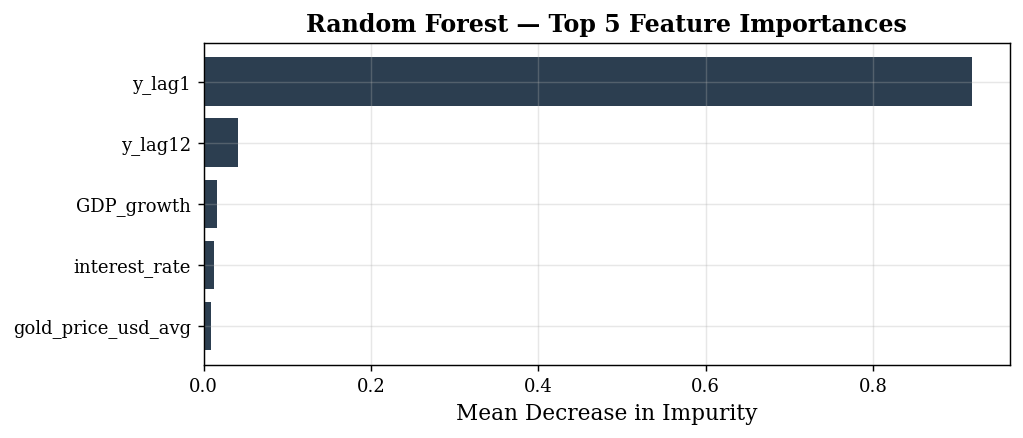

In [114]:
rf = RandomForestRegressor(
    n_estimators=300, max_depth=4, min_samples_leaf=8,
    random_state=42, n_jobs=-1)
rf.fit(X_sc_train, y_train)

rf_pred = pd.Series(rf.predict(X_sc_test), index=y_test.index)
forecasts['Random Forest'] = rf_pred
results_list.append(evaluate('Random Forest', y_test, rf_pred, y_train))

# Feature importance — top 5
fi = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
fi = fi.sort_values('Importance', ascending=False).head(5)
print("\nTop 5 Features (Random Forest):")
print(fi.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='#2c3e50')
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_title('Random Forest — Top 5 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.show()

### Model 7 — ANN (MLP)

$$\text{Input}(p) \to 128 \to 64 \to 32 \to 1$$

In [115]:
# ==========================================
# FIXED MODEL 7: ANN (MLP Regressor)
# ==========================================
mlp = MLPRegressor(
    hidden_layer_sizes=(8, 4), # Drastically reduced complexity
    activation='relu', 
    solver='lbfgs',            # lbfgs converges much better on small datasets than adam
    alpha=0.1,                 # Increased L2 regularization penalty
    max_iter=1000, 
    random_state=42
)
mlp.fit(X_sc_train, y_train)

mlp_pred = pd.Series(mlp.predict(X_sc_test), index=y_test.index)
forecasts['ANN (MLP)'] = mlp_pred
results_list.append(evaluate('ANN (MLP)', y_test, mlp_pred, y_train))

# Note: The 'lbfgs' solver does not generate a loss_curve_ in scikit-learn, 
# so we skip the plotting step here to prevent AttributeErrors.

[ANN (MLP)]  MAE=0.1504  RMSE=0.1738  R2=-15.1142  MASE=11.1025


### Model 8 — RNN (LSTM)

$$h_t = \text{LSTM}(x_t,\; h_{t-1})$$

Architecture: LSTM(64) $\to$ Dropout(0.2) $\to$ LSTM(32) $\to$ Dropout(0.2) $\to$ Dense(1).
Lookback $L = 12$.

In [116]:
%pip install tensorflow -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


LSTM — train: (144, 12, 10)  test: (24, 12, 10)
[LSTM]  MAE=0.0615  RMSE=0.0724  R2=-1.7977  MASE=4.5420


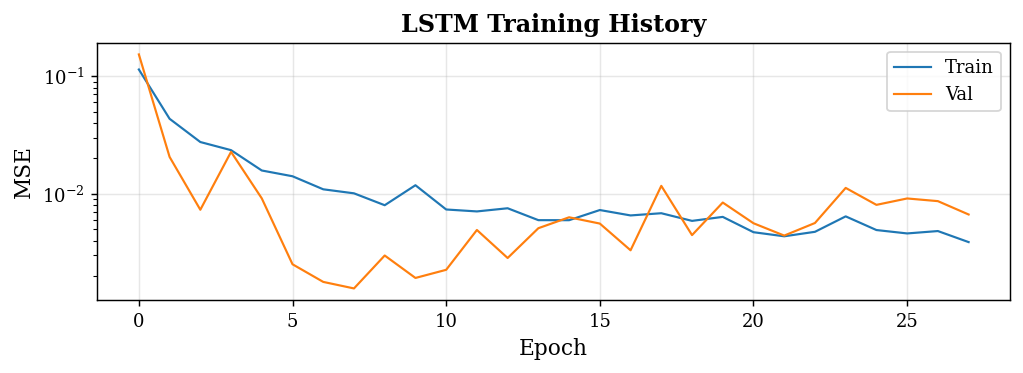

In [117]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

LOOKBACK = 12

sc_X2 = MinMaxScaler()
sc_y2 = MinMaxScaler()

feat_cols = [c for c in df_model.columns if c != 'unemployed_rate']
X_all_sc = sc_X2.fit_transform(df_model[feat_cols])
y_all_sc = sc_y2.fit_transform(df_model[['unemployed_rate']])

X_seq, y_seq, dates_seq = [], [], []
for i in range(LOOKBACK, len(X_all_sc)):
    X_seq.append(X_all_sc[i - LOOKBACK : i])
    y_seq.append(y_all_sc[i, 0])
    dates_seq.append(df_model.index[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)
dates_seq = pd.DatetimeIndex(dates_seq)

tr_mask = dates_seq <= pd.Timestamp('2023-12-01')
te_mask = dates_seq >= pd.Timestamp('2024-01-01')
X_tr, y_tr = X_seq[tr_mask], y_seq[tr_mask]
X_te, y_te = X_seq[te_mask], y_seq[te_mask]
print(f'LSTM — train: {X_tr.shape}  test: {X_te.shape}')

tf.random.set_seed(42)
lstm_model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, X_tr.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')

history = lstm_model.fit(
    X_tr, y_tr, epochs=200, batch_size=16,
    validation_split=0.15, callbacks=[EarlyStopping(patience=20, restore_best_weights=True)],
    verbose=0)

lstm_pred_sc = lstm_model.predict(X_te, verbose=0)
lstm_pred_vals = sc_y2.inverse_transform(lstm_pred_sc).flatten()
lstm_pred = pd.Series(lstm_pred_vals, index=dates_seq[te_mask])
forecasts['LSTM'] = lstm_pred
results_list.append(evaluate('LSTM', y_test.loc[lstm_pred.index], lstm_pred, y_train))

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(history.history['loss'], label='Train', lw=1.2)
ax.plot(history.history['val_loss'], label='Val', lw=1.2)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.set_title('LSTM Training History', fontweight='bold')
ax.legend(); ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 6 $\cdot$ Model Comparison

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$

Higher $R^2$ means the model explains more variance.  Pay attention to whether
`rub_kzt_diff` improves the $R^2$ compared to a baseline without it.

In [118]:
results_df = pd.DataFrame(results_list).set_index('Model').sort_values('MAE')
print(results_df.round(4).to_string())

                  MAE    RMSE       R2     MASE
Model                                          
ElasticNet     0.0117  0.0230   0.7181   0.8628
ARDL           0.0141  0.0238   0.6967   1.0440
Ridge          0.0141  0.0239   0.6966   1.0443
SARIMAX        0.0401  0.0427   0.0262   2.9600
SARIMA         0.0604  0.0682  -1.4823   4.4553
LSTM           0.0615  0.0724  -1.7977   4.5420
Random Forest  0.1157  0.1236  -7.1539   8.5364
ANN (MLP)      0.1504  0.1738 -15.1142  11.1025


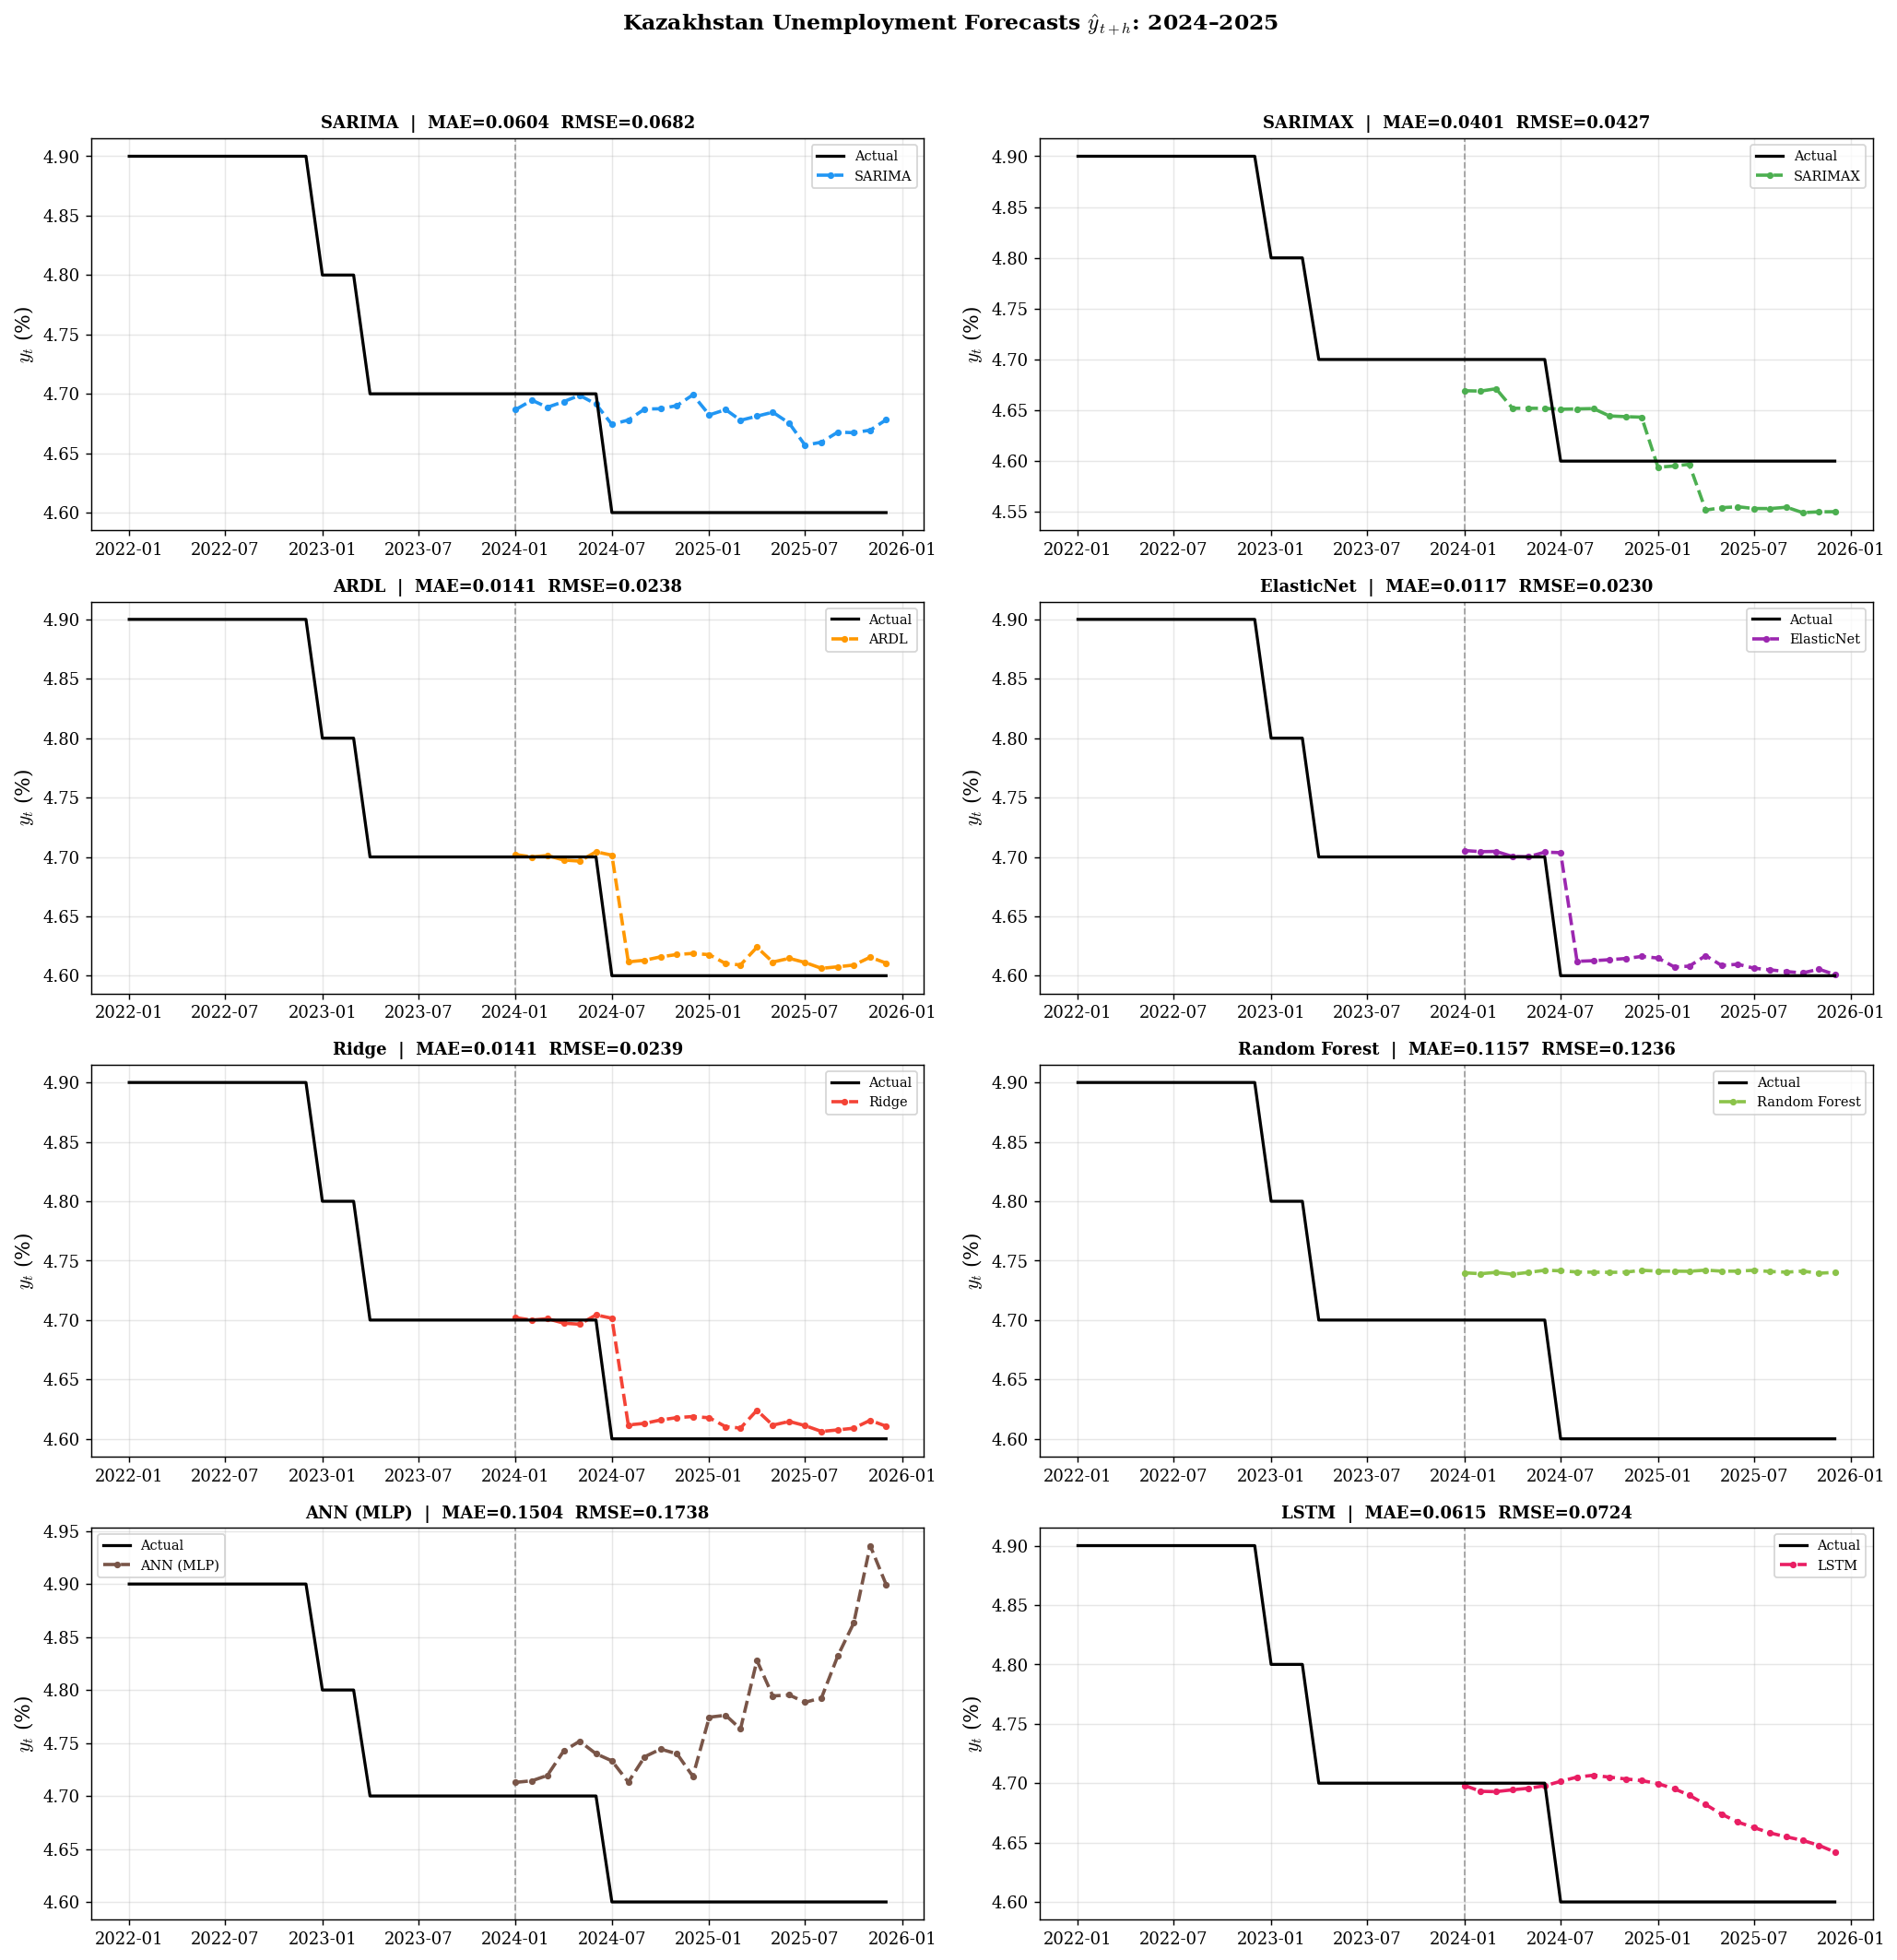

In [119]:
PALETTE = {
    'SARIMA': '#2196F3', 'SARIMAX': '#4CAF50', 'ARDL': '#FF9800',
    'ElasticNet': '#9C27B0', 'Ridge': '#F44336', 'Random Forest': '#8BC34A',
    'ANN (MLP)': '#795548', 'LSTM': '#E91E63',
}

n_models = len(forecasts)
nrows = (n_models + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, (name, pred) in enumerate(forecasts.items()):
    ax = axes[i]
    ctx = y.loc['2022-01-01':]
    ax.plot(ctx.index, ctx.values, color='black', lw=1.8, label='Actual', zorder=3)
    ax.axvline(pd.Timestamp('2024-01-01'), color='grey', ls='--', alpha=.7, lw=1)
    ax.plot(pred.index, pred.values, color=PALETTE.get(name, '#999'),
            lw=2, ls='--', marker='o', ms=3, label=name)
    mae_v = mean_absolute_error(y.loc[pred.index], pred)
    rmse_v = np.sqrt(mean_squared_error(y.loc[pred.index], pred))
    ax.set_title(f'{name}  |  MAE={mae_v:.4f}  RMSE={rmse_v:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(r'$y_t$ (%)')
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    r'Kazakhstan Unemployment Forecasts $\hat{y}_{t+h}$: 2024–2025',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

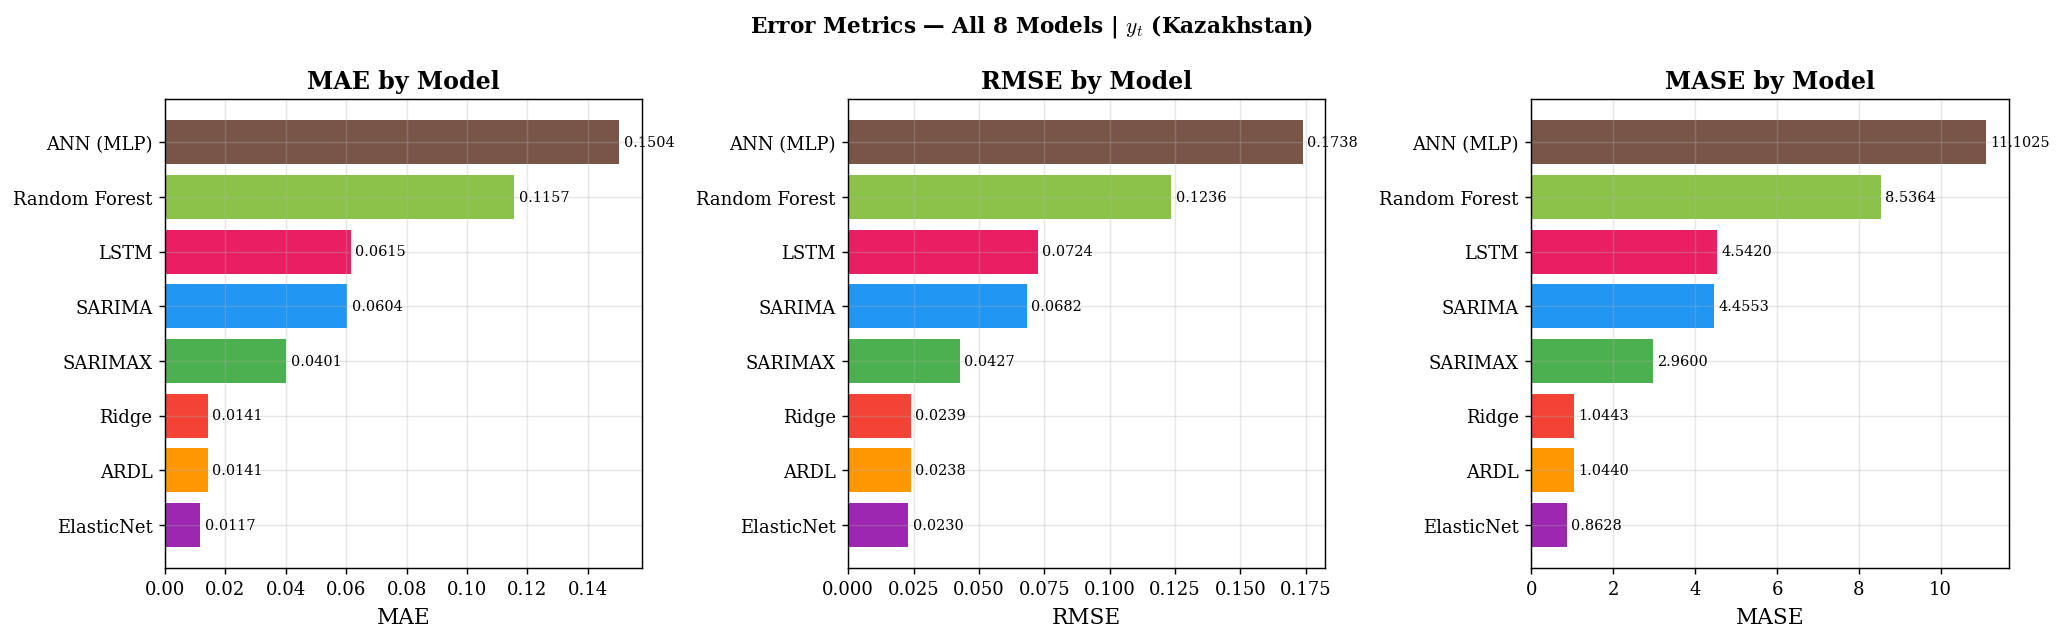

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, m in zip(axes, ['MAE', 'RMSE', 'MASE']):
    vals = results_df[m].sort_values()
    colors = [PALETTE.get(idx, '#999') for idx in vals.index]
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_xlabel(m)
    ax.set_title(f'{m} by Model', fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, vals.values):
        ax.text(v + vals.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f'{v:.4f}', va='center', fontsize=8)
plt.suptitle(r'Error Metrics — All 8 Models | $y_t$ (Kazakhstan)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 $\cdot$ Data Sufficiency Assessment

### Current Feature Set
| Available | Status |
|-----------|--------|
| `y_lag1`, `y_lag12` | $\checkmark$ |
| `usd_kzt_diff` | $\checkmark$ |
| `Oil_crude_brent_diff` | $\checkmark$ |
| `Base_Rate_diff` | $\checkmark$ |
| `rub_kzt_diff` | $\checkmark$ (derived via yfinance) |
| `GDP_growth`, `interest_rate`, `gold_price_usd_avg` | $\checkmark$ |
| `usd_kzt_volatility` | $\checkmark$ (derived) |

### Missing — Upload to Improve $R^2$

| Dataset | Variable | Why it matters | Source |
|---------|----------|----------------|--------|
| **STEI** | Short-Term Economic Indicator | Composite leading indicator of economic activity | stat.gov.kz |
| **Retail Trade** | `Retail_Trade_diff` | Captures consumer demand — leading indicator for services employment | stat.gov.kz |
| **Industrial Production** | `Industrial_Production_diff` | Captures manufacturing activity — leading indicator for industrial employment | stat.gov.kz |
| **Labour Force Participation** | `LFPR` | Denominator changes affect $y_t$ mechanically | stat.gov.kz |
| **Job Vacancies** | `vacancies` | Beveridge curve — inverse of unemployment | enbek.kz |
| **Net Migration** | `migration` | Labour supply shocks | stat.gov.kz |

In [3]:
import pandas as pd

# List of sources: (file_path, sheet_name_or_None)
# For CSV files, sheet_name is set to None.
sources = [
    ("data/indicators/main_ind_ML_imputed.csv", None),                     # CSV
    ("data/cpi_data/dataset_for_forecast_2026111.xlsx", "Sheet3"),
    ("data/cpi_data/diploma_dataset.xlsx", "Sheet3"),
    ("data/unemp/National Bank Base Rate.xlsx", "base_rate"),
    ("data/unemp/POILBREUSDM.xlsx", "Monthly"),
    ("data/unemp/unemployment_rate.xlsx", "rate"),
    ("data/unemp/USD_TENGE.xlsx", "exch_rate"),
]

for path, sheet in sources:
    try:
        # Read the file
        if path.endswith('.csv'):
            df = pd.read_csv(path)
            sheet_info = "CSV (no sheet)"
        else:
            df = pd.read_excel(path, sheet_name=sheet)
            sheet_info = f"sheet='{sheet}'"
        
        # Output the metadata
        print(f"File path : {path}")
        print(f"Sheet     : {sheet_info}")
        print(f"Shape     : {df.shape[0]} rows x {df.shape[1]} columns")
        print(f"Columns   : {df.columns.tolist()}")
        print("-" * 60)
        
    except Exception as e:
        print(f"Error reading {path} (sheet: {sheet}): {e}")
        print("-" * 60)

File path : data/indicators/main_ind_ML_imputed.csv
Sheet     : CSV (no sheet)
Shape     : 193 rows x 5 columns
Columns   : ['Date', 'Economically Active Population (thsd)', 'Employed Population (thsd)', 'Unemployed Population (thsd)', 'Unemployment Rate (%)']
------------------------------------------------------------
File path : data/cpi_data/dataset_for_forecast_2026111.xlsx
Sheet     : sheet='Sheet3'
Shape     : 192 rows x 19 columns
Columns   : ['Date', 'log_usd_kzt', 'log_oil_brent', 'log_gold_price', 'log_rub_kzt', 'log_wheat_price', 'log_sugar_price', 'russian_cpi', 'M2_yoy', 'fuel92_yoy', 'gdp_stei', 'interest_rate', 'Unemployment', 'PPI_yoy', 'log_export', 'log_import', 'nominal_wage_yoy_pct', 'real_wage_yoy_pct', 'total_cpi_yoy']
------------------------------------------------------------
File path : data/cpi_data/diploma_dataset.xlsx
Sheet     : sheet='Sheet3'
Shape     : 192 rows x 13 columns
Columns   : ['Date', 'cpi_russia', 'total_cpi_yoy', 'gold_price_usd_avg', 'usd_